# Phase II Vectorized Code Validation

This notebook validates the assignment Phase II vectorized implementation against the serial implementation. It runs the same coupled artificial-compressibility SGS case twice with identical settings except for `vectorize`, overlays the vertical centerline velocity and pressure profiles, reports max absolute differences, and compares runtime.

In [1]:
from pathlib import Path
import os
import shutil
import time

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np

if Path.cwd().name != "start-code" and (Path.cwd() / "start-code").exists():
    os.chdir(Path.cwd() / "start-code")

plot_dir = Path("Phase II Vectorization Validation")
plot_dir.mkdir(exist_ok=True)

print(f"Working directory: {Path.cwd()}")
print(f"Validation plot directory: {plot_dir.resolve()}")

Working directory: /Users/windy/mae4100-courseproject2/start-code
Validation plot directory: /Users/windy/mae4100-courseproject2/start-code/Phase II Vectorization Validation


In [2]:
MAIN_PLOT_FILES = [
    "ucontour.png",
    "vcontour.png",
    "pcontour.png",
    "residualcomponent.png",
    "residual.png",
]


def patched_solver_source(vectorize):
    solver_path = Path("main_solver.py")
    source = solver_path.read_text()

    replacements = {
        "vectorize = False":
            f"vectorize = {vectorize}",
    }

    for old, new in replacements.items():
        if old not in source:
            raise RuntimeError(f"Could not find expected setting in {solver_path}: {old}")
        source = source.replace(old, new, 1)

    return solver_path, source


def archive_solver_plots(label):
    for filename in MAIN_PLOT_FILES:
        src = Path(filename)
        if src.exists():
            dst = plot_dir / f"{label}_{filename}"
            if dst.exists():
                dst.unlink()
            shutil.move(str(src), str(dst))


def run_solver_case(label, vectorize):
    solver_path, source = patched_solver_source(vectorize)
    namespace = {
        "__file__": str(solver_path.resolve()),
        "__name__": "__main__",
    }

    print(f"\nRunning {label} case with vectorize = {vectorize}")
    start_time = time.perf_counter()
    exec(compile(source, str(solver_path), "exec"), namespace)
    elapsed_time = time.perf_counter() - start_time
    archive_solver_plots(label)
    plt.close("all")

    return {
        "label": label,
        "vectorize": vectorize,
        "elapsed_time_sec": elapsed_time,
        "u": namespace["u"].copy(),
        "n": namespace["n"],
        "conv": namespace["conv"],
        "res": np.array(namespace["res"], copy=True),
        "convVector": np.array(namespace["convVector"], copy=True),
        "xmax": namespace["xmax"],
        "xmin": namespace["xmin"],
        "ymax": namespace["ymax"],
        "ymin": namespace["ymin"],
    }

In [3]:
serial = run_solver_case("serial", False)
vectorized = run_solver_case("vectorized", True)

u_serial = serial["u"]
u_vectorized = vectorized["u"]
imax, jmax, _ = u_serial.shape
i_mid = (imax - 1) // 2
y_profile = np.linspace(serial["ymin"], serial["ymax"], jmax)

centerline_diffs = {
    "max_abs_u_centerline": np.max(np.abs(u_serial[i_mid, :, 1] - u_vectorized[i_mid, :, 1])),
    "max_abs_v_centerline": np.max(np.abs(u_serial[i_mid, :, 2] - u_vectorized[i_mid, :, 2])),
    "max_abs_p_centerline": np.max(np.abs(u_serial[i_mid, :, 0] - u_vectorized[i_mid, :, 0])),
}

field_diffs = {
    "max_abs_u_field": np.max(np.abs(u_serial[:, :, 1] - u_vectorized[:, :, 1])),
    "max_abs_v_field": np.max(np.abs(u_serial[:, :, 2] - u_vectorized[:, :, 2])),
    "max_abs_p_field": np.max(np.abs(u_serial[:, :, 0] - u_vectorized[:, :, 0])),
}

speedup = serial["elapsed_time_sec"] / vectorized["elapsed_time_sec"]

timing_table = f"""
| Solver implementation | Vectorized? | Iterations | Final convergence | Wall time (s) | Speedup vs serial |
|---|---:|---:|---:|---:|---:|
| Serial | No | {serial['n']} | {serial['conv']:.6e} | {serial['elapsed_time_sec']:.3f} | 1.00x |
| Vectorized | Yes | {vectorized['n']} | {vectorized['conv']:.6e} | {vectorized['elapsed_time_sec']:.3f} | {speedup:.2f}x |
"""

display(Markdown("## Computational Time Comparison" + timing_table))

print("\nConvergence summary")
print(f"Serial:     iteration = {serial['n']}, conv = {serial['conv']:.6e}, res = {serial['res']}")
print(f"Vectorized: iteration = {vectorized['n']}, conv = {vectorized['conv']:.6e}, res = {vectorized['res']}")

print("\nVertical centerline max absolute differences")
for name, value in centerline_diffs.items():
    print(f"{name}: {value:.6e}")

print("\nFull-field max absolute differences")
for name, value in field_diffs.items():
    print(f"{name}: {value:.6e}")


Running serial case with vectorize = False
Iter.    Time (s)   dt (s)      Continuity    x-Momentum    y-Momentum
0   9.765625e-04   9.765625e-04   1.000000e+00   1.000000e+00   1.000000e+00
199   1.953125e-01   9.765625e-04   1.019877e-04   8.058646e-07   5.719258e-04
399   3.906250e-01   9.765625e-04   1.181315e-07   4.698803e-10   2.707759e-07
599   5.859375e-01   9.765625e-04   2.320590e-10   6.446902e-13   5.006747e-10
651 6.367188e-01 4.626943e-11 1.240270e-13 9.913961e-11
Elapsed time is  0.4575631618499756 sec
[0. 0. 0.] [0. 0. 0.] [0. 0. 0.]



Running vectorized case with vectorize = True
Iter.    Time (s)   dt (s)      Continuity    x-Momentum    y-Momentum
0   9.765625e-04   9.765625e-04   1.000000e+00   1.000000e+00   1.000000e+00
199   1.953125e-01   9.765625e-04   1.019877e-04   8.058646e-07   5.719258e-04
399   3.906250e-01   9.765625e-04   1.181315e-07   4.698803e-10   2.707759e-07


599   5.859375e-01   9.765625e-04   2.320590e-10   6.446902e-13   5.006747e-10
651 6.367188e-01 4.626943e-11 1.240270e-13 9.913961e-11
Elapsed time is  0.3681602478027344 sec
[0. 0. 0.] [0. 0. 0.] [0. 0. 0.]


## Computational Time Comparison
| Solver implementation | Vectorized? | Iterations | Final convergence | Wall time (s) | Speedup vs serial |
|---|---:|---:|---:|---:|---:|
| Serial | No | 651 | 9.913961e-11 | 0.830 | 1.00x |
| Vectorized | Yes | 651 | 9.913961e-11 | 0.580 | 1.43x |



Convergence summary
Serial:     iteration = 651, conv = 9.913961e-11, res = [4.62694311e-11 1.24026989e-13 9.91396067e-11]
Vectorized: iteration = 651, conv = 9.913961e-11, res = [4.62694311e-11 1.24026989e-13 9.91396067e-11]

Vertical centerline max absolute differences
max_abs_u_centerline: 0.000000e+00
max_abs_v_centerline: 0.000000e+00
max_abs_p_centerline: 0.000000e+00

Full-field max absolute differences
max_abs_u_field: 0.000000e+00
max_abs_v_field: 0.000000e+00
max_abs_p_field: 0.000000e+00


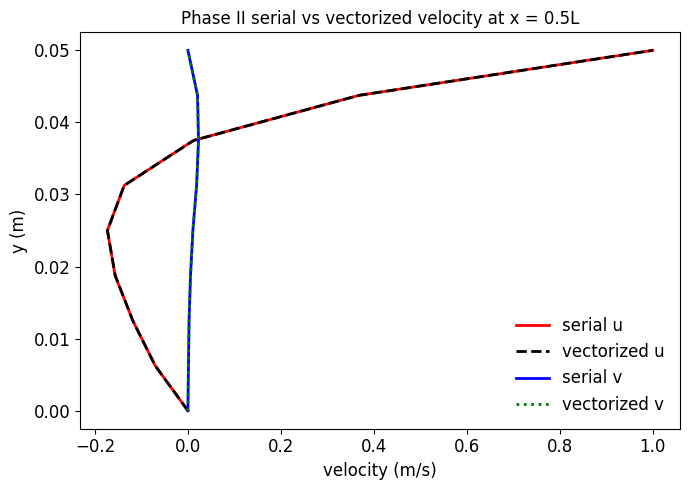

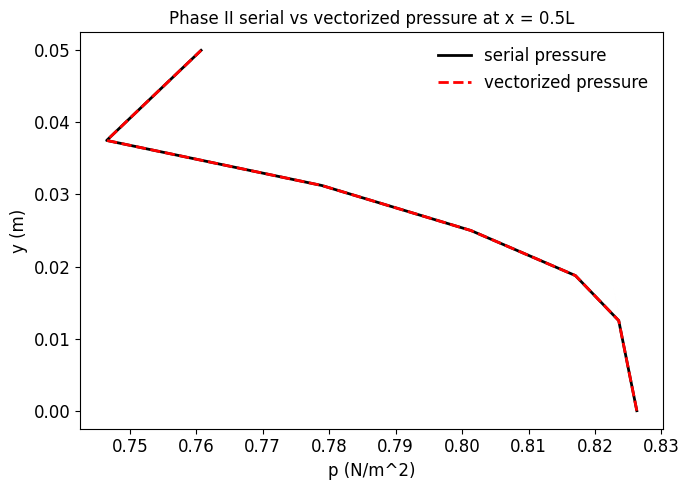

In [4]:
fontsize = 12

plt.figure(figsize=(7, 5))
plt.plot(u_serial[i_mid, :, 1], y_profile, "-r", linewidth=2, label="serial u")
plt.plot(u_vectorized[i_mid, :, 1], y_profile, "--k", linewidth=2, label="vectorized u")
plt.plot(u_serial[i_mid, :, 2], y_profile, "-b", linewidth=2, label="serial v")
plt.plot(u_vectorized[i_mid, :, 2], y_profile, ":g", linewidth=2, label="vectorized v")
plt.xlabel("velocity (m/s)", fontsize=fontsize)
plt.ylabel("y (m)", fontsize=fontsize)
plt.title("Phase II serial vs vectorized velocity at x = 0.5L", fontsize=fontsize)
plt.legend(loc="best", fontsize=fontsize, frameon=False)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()
plt.savefig(plot_dir / "serial_vs_vectorized_velocity_centerline.png", dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(u_serial[i_mid, :, 0], y_profile, "-k", linewidth=2, label="serial pressure")
plt.plot(u_vectorized[i_mid, :, 0], y_profile, "--r", linewidth=2, label="vectorized pressure")
plt.xlabel("p (N/m^2)", fontsize=fontsize)
plt.ylabel("y (m)", fontsize=fontsize)
plt.title("Phase II serial vs vectorized pressure at x = 0.5L", fontsize=fontsize)
plt.legend(loc="best", fontsize=fontsize, frameon=False)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.tight_layout()
plt.savefig(plot_dir / "serial_vs_vectorized_pressure_centerline.png", dpi=300)
plt.show()